In [76]:
import numpy as np #librería para operaciones algebraicas y numéricas
import pandas as pd #librería para manejo de datos

#programo el método bisección
def biseccion(a, b , tol, itmax = 100): 
        df = pd.DataFrame(columns=('ai','bi','pi','cond','f_ai_f_pi'))
        a = a 
        b = b
        contador = 0  
        x0, x1 = a, b 
        if(f(a) * f(b)>0):         #condicion de aplicabilidad del método
            print( "El método no resuelve este tipo de raíz")
            return
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            x0 = x1                                                 
            x1 = (a + b)/2                      
            f_ai_f_pi = f(a) * f(x1)
            if f_ai_f_pi < 0:      
                df.loc[contador] = [a,b,(a+b)/2,'<0',f_ai_f_pi]
                b = x1
            else:
                df.loc[contador] = [a,b,(a+b)/2,'>0',f_ai_f_pi]
                a = x1
            contador += 1                      
        error = abs((x1 - x0) / x1)
        print('El método de bisección convergió en',contador,'iteraciones')
        return df

# Descripción del Método de Bisección

El método de bisección es un algoritmo numérico utilizado como paso inicial para aproximar el fondo de un río. Este método sirve como un método de arranque, y posteriormente se aplicarán dos métodos de refinamiento para obtener resultados más precisos.

## Contexto:
- Se evalúa la función con dos valores de pendiente: `z = 4` y `z = 6`.
- El objetivo es encontrar una aproximación inicial que cumpla con las condiciones del problema.

## Pasos del Método:
1. **Definir el intervalo inicial:** Seleccionar los valores iniciales `a` y `b` tales que `f(a) * f(b) < 0`.
2. **Calcular el punto medio:** Determinar el punto medio del intervalo, `p = (a + b) / 2`.
3. **Evaluar la función en el punto medio:** Verificar el signo de `f(p)` y compararlo con los extremos del intervalo.
4. **Actualizar el intervalo:**
   - Si `f(a) * f(p) < 0`, la raíz está en `[a, p]`.
   - Si `f(p) * f(b) < 0`, la raíz está en `[p, b]`.
5. **Repetir:** Continuar iterando hasta que el intervalo sea lo suficientemente pequeño o se alcance la tolerancia deseada.

Este método garantiza la convergencia si se cumplen las condiciones iniciales y proporciona una base sólida para los métodos de refinamiento posteriores.

In [77]:
#defino el intervalo de arranque y la tolerancia
A=2
B=6
pendiente_veriles = 4
tolerancia=10**(-3)
def f(y):
    # Constantes dadas por el enunciado [1]
    n = 0.025 
    b = 20
    S = 0.002
    z = pendiente_veriles 
    Q_real = 410
    
    # Fórmulas de la sección trapezoidal [2]
    A = (b + z*y)*y
    P = b + 2*y * ((1 + z**2)**0.5)
    R = A / P
    
    # Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
    Q_calc = (1/n) * A * (R**(2/3)) * (S**0.5)
    return Q_calc - Q_real

caso_z4=biseccion(A, B, tolerancia)


El método de bisección convergió en 11 iteraciones


In [78]:
caso_z4.tail(3)

,ai,bi,pi,cond,f_ai_f_pi
8,3.609375,3.625000,3.617188,<0,-0.720230
9,3.609375,3.617188,3.613281,<0,-0.134808
10,3.609375,3.613281,3.611328,>0,0.157644


In [79]:
pendiente_veriles = 6
A=2
B=6
tolerancia=10**(-3)
def f(y):
    # Constantes dadas por el enunciado [1]
    n = 0.025 
    b = 20
    S = 0.002
    z = pendiente_veriles 
    Q_real = 410
    
    # Fórmulas de la sección trapezoidal [2]
    A = (b + z*y)*y
    P = b + 2*y * ((1 + z**2)**0.5)
    R = A / P
    
    # Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
    Q_calc = (1/n) * A * (R**(2/3)) * (S**0.5)
    return Q_calc - Q_real
caso_z6=biseccion(A, B, tolerancia)
caso_z6.tail(3)

El método de bisección convergió en 11 iteraciones


,ai,bi,pi,cond,f_ai_f_pi
8,3.343750,3.359375,3.351562,>0,6.507866
9,3.351562,3.359375,3.355469,>0,1.363071
10,3.355469,3.359375,3.357422,>0,0.222812


In [80]:
#programo el método Newton Raphson
def Newton_Raphson(x0 , tol, itmax = 100): 
        df = pd.DataFrame(columns=('xcero','xuno'))
        x0 = x0 
        contador = 0  
        x1 = x0-f(x0)/fd(x0)
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            df.loc[contador] = [x0,x1]
            x0 = x1                                                 
            x1 = x0-f(x0)/fd(x0)                 
            contador += 1                      
        print('El método de Newton Raphson convergió en',contador,'iteraciones')
        return df

## Newton-Raphson para z = 4

In [81]:
import sympy as sp

# Definimos las constantes simbólicamente
n, b, S, z, Q_real, y = sp.symbols('n b S z Q_real y')

# Fórmulas de la sección trapezoidal [2]
A = (b + z*y)*y
P = b + 2*y * sp.sqrt(1 + z**2)
R = A / P

# Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
Q_calc = (1/n) * A * (R**(2/3)) * sp.sqrt(S)
f_sympy = Q_calc - Q_real

# Derivada de la función con respecto a y
f_derivada = sp.diff(f_sympy, y)
# Valores del enunciado [3]
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 4  # O z: 6 para el segundo caso
}


f_num = f_sympy.subs(valores)
fd_num = f_derivada.subs(valores)

# 3. Conversión a funciones numéricas (SIN repetir las líneas erróneas)
f = sp.lambdify(y, f_num)
fd = sp.lambdify(y, fd_num)

# 4. Ejecución del método
x0 = 3.6
tolerancia = 1e-8

refinado_z4 = Newton_Raphson(x0, tolerancia)
refinado_z4.tail()

El método de Newton Raphson convergió en 2 iteraciones


,xcero,xuno
0,3.600000,3.612404
1,3.612404,3.612381


## Newton-Raphson para z = 6

In [82]:
import sympy as sp

# Definimos las constantes simbólicamente
n, b, S, z, Q_real, y = sp.symbols('n b S z Q_real y')

# Fórmulas de la sección trapezoidal [2]
A = (b + z*y)*y
P = b + 2*y * sp.sqrt(1 + z**2)
R = A / P

# Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
Q_calc = (1/n) * A * (R**(2/3)) * sp.sqrt(S)
f_sympy = Q_calc - Q_real

# Derivada de la función con respecto a y
f_derivada = sp.diff(f_sympy, y)
# Valores del enunciado [3]
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 6
}


f_num = f_sympy.subs(valores)
fd_num = f_derivada.subs(valores)

# 3. Conversión a funciones numéricas (SIN repetir las líneas erróneas)
f = sp.lambdify(y, f_num)
fd = sp.lambdify(y, fd_num)

# 4. Ejecución del método
x0 = 3.3
tolerancia = 1e-8

refinado_z6 = Newton_Raphson(x0, tolerancia)
refinado_z6.tail()

El método de Newton Raphson convergió en 3 iteraciones


,xcero,xuno
0,3.300000,3.359181
1,3.359181,3.358565
2,3.358565,3.358565


## Aproximacion con Secante

In [83]:

#programo el método Secante
def secante(a , b, tol, itmax = 100): 
        np.seterr('raise')
        df2 = pd.DataFrame(columns=('xcero','xuno','xdos'))
        x0 = a
        x1 = b
        contador = 0  
        x2 = x1-f(x1)*(x1-x0)/(f(x1)-f(x0))
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            df2.loc[contador] = [x0,x1,x2]
            x0 = x1                                                 
            x1 = x2
            x2 = x1-(f(x1)*(x1-x0))/(f(x1)-f(x0))
            contador += 1                      
        print('El método Secante convergió en',contador,'iteraciones')
        return df2

## Secante para z = 4

El método Secante convergió en 4 iteraciones


,xcero,xuno,xdos
0,3.500000,3.700000,3.610889
1,3.700000,3.610889,3.612362
2,3.610889,3.612362,3.612381
3,3.612362,3.612381,3.612381


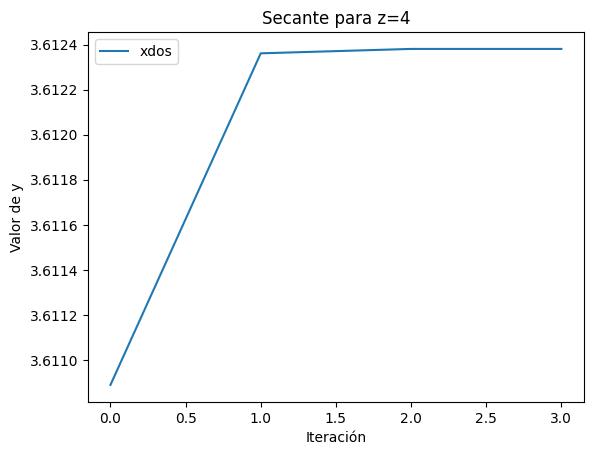

In [84]:

tolerancia=10**(-8)
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 4
}
f_num = f_sympy.subs(valores)

f = sp.lambdify(y, f_num)
ejemplo2=secante(3.5,3.7, tolerancia)
ejemplo2.plot(y='xdos', kind='line', title='Secante para z=4', ylabel='Valor de y', xlabel='Iteración')
ejemplo2.tail()

## Secante para z = 6

El método Secante convergió en 4 iteraciones


,xcero,xuno,xdos
0,3.200000,3.400000,3.357386
1,3.400000,3.357386,3.358557
2,3.357386,3.358557,3.358565
3,3.358557,3.358565,3.358565


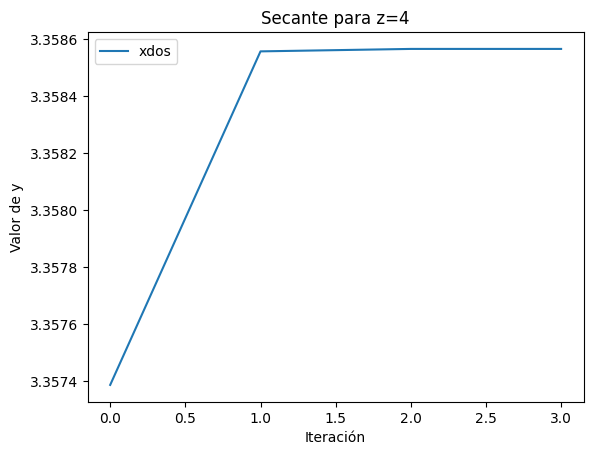

In [85]:

tolerancia=10**(-8)
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 6
}
f_num = f_sympy.subs(valores)

f = sp.lambdify(y, f_num)
ejemplo2=secante(3.2,3.4, tolerancia)
ejemplo2.plot(y='xdos', kind='line', title='Secante para z=4', ylabel='Valor de y', xlabel='Iteración')
ejemplo2.tail()